In [8]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))  # adjust levels to reach your root

from experiments.init_models import HydraModel, MrSQMModel

In [9]:
import numpy as np
import pandas as pd
from sklearn import metrics
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import timeit

from sklearn.linear_model import RidgeClassifierCV

from aeon.datasets import load_classification  
import warnings

In [3]:
# warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn")

In [4]:
ds = "Coffee"
X_train, y_train = load_classification(name=ds,split="train")
X_test, y_test = load_classification(name=ds,split="test")

print(ds)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

Coffee
(28, 1, 286) (28,)
(28, 1, 286) (28,)


In [7]:
clf = MrSQMClassifier().fit(X_train,y_train)

NameError: name 'MrSQMClassifier' is not defined

In [6]:
y_pred = clf.predict(X_test)
print(metrics.accuracy_score(y_test, y_pred))

NameError: name 'clf' is not defined

In [ ]:
tfm = MrSQMTransformer()

In [ ]:
X_train_transform = tfm.fit_transform(X_train,y_train)
X_test_transform = tfm.transform(X_test)

In [ ]:
# use ridgecv classifier
ridge = RidgeClassifierCV(alphas = np.logspace(-3, 3, 10)).fit(X_train_transform,y_train)
y_pred = ridge.predict(X_test_transform)
print(metrics.accuracy_score(y_test, y_pred))

1.0


In [ ]:
# This example visualise the saliency map of the 1st sample (class '0') in the Coffee dataset 
clf = MrSQMClassifier(nsax=5,nsfa=0).fit(X_train,y_train)
x = X_train[0,0,:]
w = clf.get_saliency_map(x)[0,:]

/Users/philiplynch/college/02_semester/ai4ts/assignments/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


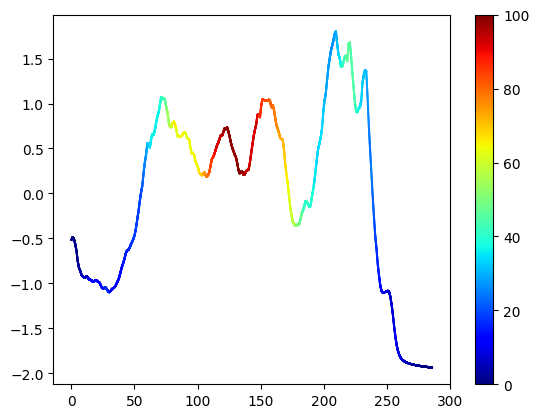

In [ ]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt



def transform(X):
    ma,mi = np.max(X), np.min(X)
    X = (X - mi)/(ma-mi)
    return X*100
weight = abs(w)
weight = transform(weight)
ts = np.squeeze(x)
   
max_length1, max_length2 = ts.shape[0],10000 #
x1 = np.linspace(0,max_length1,num = max_length1)
x2 = np.linspace(0,max_length1,num = max_length2)
y1 = ts

f = interp1d(x1, y1) # interpolate time series
fcas = interp1d(x1, weight) # interpolate weight color
weight = fcas(x2) # convert vector of original weight vector to new weight vector

plt.scatter(x2,f(x2), c = weight, cmap = 'jet', marker='.', s= 1,vmin=0,vmax = 100)
# plt.xlabel('Explanation for index %d, dataset %s' %(idx, ds))
cbar = plt.colorbar(orientation = 'vertical')


plt.show()

,dataset,model,accuracy,total_time
0,ACSF1,mpshydra,0.880000,1.218343
1,Adiac,mpshydra,0.813299,0.368891
2,AllGestureWiimoteX,mpshydra,0.690000,1.447105
3,AllGestureWiimoteY,mpshydra,0.711429,1.439540
4,AllGestureWiimoteZ,mpshydra,0.678571,1.435548
...,...,...,...,...
123,Wine,mpshydra,0.888889,0.235405
124,WordSynonyms,mpshydra,0.744514,0.827238
125,Worms,mpshydra,0.740260,1.022897
126,WormsTwoClass,mpshydra,0.766234,0.780158
